In [1]:
%pip install networkx matplotlib pandas tqdm gcastle torch pgmpy ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [2]:
from castle.common import GraphDAG
from castle.datasets import IIDSimulation, DAG
import pandas as pd

# gera um DAG aleatório com pesos
weighted_random_dag = DAG.erdos_renyi(n_nodes=10, n_edges=37, weight_range=(0.5, 2.0), seed=1)

# gera um dataset a partir do DAG
dataset = IIDSimulation(W=weighted_random_dag, n=10000, method='linear', sem_type='gauss')
true_causal_matrix, X = dataset.B, dataset.X

df_X = pd.DataFrame(X, columns=[f'X{i}' for i in range(X.shape[1])])
df_X.head()

2026-04-07 22:02:46,099 - /home/luis/Documents/projects/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/datasets/simulator.py[line:270] - INFO: Finished synthetic dataset


,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9
0,30.800820,-2.416748,2.991407,-47.086190,-4.875393,49.405483,1.873301,0.228963,10.994710,-5.370500
1,11.217284,-0.430895,1.632563,-18.790125,-2.115744,14.778377,1.022586,-0.499538,3.551683,5.595355
2,-10.091728,0.372006,-0.781766,15.209036,2.250993,-15.411530,-0.903838,-0.024721,-3.083979,1.203403
3,-16.937488,1.141997,-3.177026,26.510421,2.436426,-30.012005,0.159320,-0.297772,-7.331510,6.760971
4,-22.611154,2.275507,-3.484673,34.503024,3.537802,-33.565285,-1.595591,-0.095119,-7.472992,-1.446310


2026-04-07 22:02:48,121 - /home/luis/Documents/projects/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/backend/__init__.py[line:36] - INFO: You can use `os.environ['CASTLE_BACKEND'] = backend` to set the backend(`pytorch` or `mindspore`).
2026-04-07 22:02:48,162 - /home/luis/Documents/projects/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/algorithms/__init__.py[line:36] - INFO: You are using ``pytorch`` as the backend.
2026-04-07 22:02:49,723 - /home/luis/Documents/projects/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:195] - INFO: [start]: n=10000, d=10, iter_=100, h_=1e-08, rho_=1e+16
2026-04-07 22:02:52,725 - /home/luis/Documents/projects/genetic_causal_graph/.venv/lib/python3.12/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 0] h=6.919e-01, loss=1484.012, rho=1.0e+00
2026-04-07 22:02:55,281 - /home/luis/Documents/projects/genetic_causal_graph/.venv/lib/py

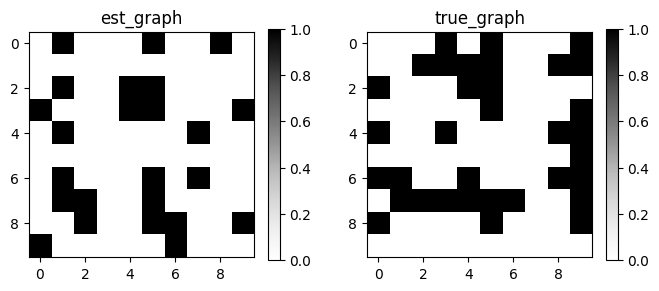

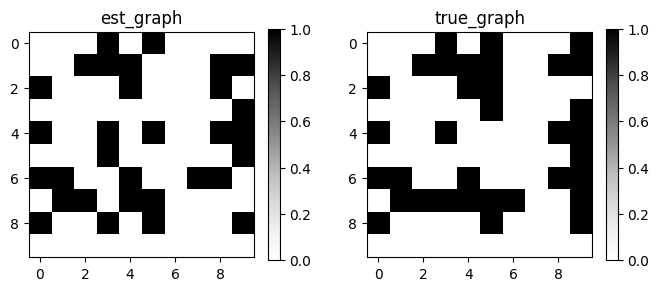

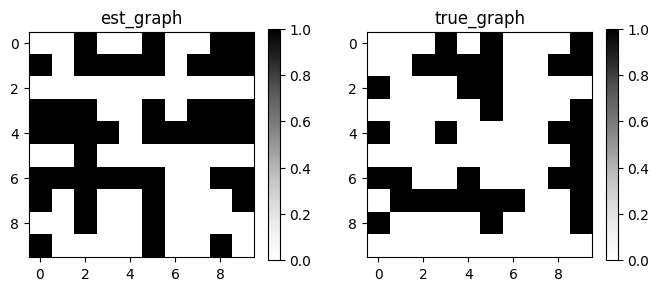

/home/luis/Documents/projects/genetic_causal_graph/.venv/lib/python3.12/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (
2026-04-07 22:04:01,433 - /home/luis/Documents/projects/genetic_causal_graph/.venv/lib/python3.12/site-packages/pgmpy/utils/utils.py[line:405] - INFO:  Datatype (N=numerical, C=Categorical Unordered,O=Categorical Ordered)inferred from data: 
 {'X0': 'N', 'X1': 'N', 'X2': 'N', 'X3': 'N', 'X4': 'N', 'X5': 'N', 'X6': 'N', 'X7': 'N', 'X8': 'N', 'X9': 'N'}
2026-04-07 22:04:01,466 - /home/luis/Documents/projects/genetic_causal_graph/.venv/lib/python3.12/site-packages/pgmpy/utils/utils.py[line:405] - INFO:  Datatype (N=numerical, C=Categorical Unordered,O=Categorical Ordered)inferred from data: 
 {'X0': 'N', 'X1': 'N', 'X2': 'N', 'X3': 'N', 'X4': 'N', 'X5': 'N', 'X6': 'N', 'X7': 'N', 'X8': 'N', 'X9': 'N'}
2

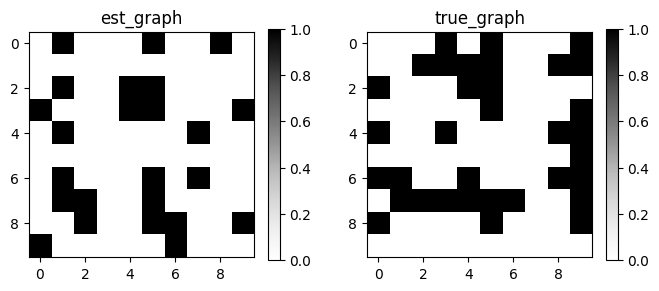

In [3]:
from castle.algorithms import PC, Notears, GES
from castle.metrics import MetricsDAG

pc = PC()
pc.learn(X)

notears = Notears()
notears.learn(X)

ges = GES()
ges.learn(X)

##

## ## ##

GraphDAG(pc.causal_matrix, true_causal_matrix, 'result')
GraphDAG(notears.causal_matrix, true_causal_matrix, 'result')
GraphDAG(ges.causal_matrix, true_causal_matrix, 'result')

from genetic_discovery.main import genetic_discovery

initial_population = [pc.causal_matrix, notears.causal_matrix, ges.causal_matrix]
best_dag = genetic_discovery(data=X ,initial_population=initial_population, max_generations=30,n_childrens=30, n_population=30, mutation_rate=0.3, crossover_rate=0.4)

GraphDAG(best_dag, true_causal_matrix, 'result')

In [4]:
from castle.metrics import MetricsDAG
metrics = MetricsDAG(true_causal_matrix, best_dag)
display(metrics.metrics)

metrics = MetricsDAG(true_causal_matrix, pc.causal_matrix)
display(metrics.metrics)

metrics = MetricsDAG(true_causal_matrix, notears.causal_matrix)
display(metrics.metrics)

metrics = MetricsDAG(true_causal_matrix, ges.causal_matrix)
display(metrics.metrics)

{'fdr': 0.6765,
 'tpr': 0.4583,
 'fpr': 1.0952,
 'shd': 26,
 'nnz': 34,
 'precision': np.float64(0.3235),
 'recall': np.float64(0.4583),
 'F1': np.float64(0.3793),
 'gscore': np.float64(0.0)}

{'fdr': 0.6765,
 'tpr': 0.4583,
 'fpr': 1.0952,
 'shd': 26,
 'nnz': 34,
 'precision': np.float64(0.3235),
 'recall': np.float64(0.4583),
 'F1': np.float64(0.3793),
 'gscore': np.float64(0.0)}

{'fdr': 0.2353,
 'tpr': 0.8387,
 'fpr': 0.5714,
 'shd': 11,
 'nnz': 34,
 'precision': np.float64(0.7647),
 'recall': np.float64(0.8387),
 'F1': np.float64(0.8),
 'gscore': np.float64(0.5806)}

{'fdr': 0.3235,
 'tpr': 0.5,
 'fpr': 11.0,
 'shd': 20,
 'nnz': 34,
 'precision': np.float64(0.6765),
 'recall': np.float64(0.5),
 'F1': np.float64(0.575),
 'gscore': np.float64(0.2609)}